# Deep Learning for Portfolio Optimization

**Docker image**: `ml4t-gpu`

> **GPU recommended**: This notebook trains models with PyTorch/CUDA. It will run on CPU
> but training may be very slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 17_portfolio_construction/11_dl_portfolio_allocation.py
> ```


This notebook implements end-to-end portfolio allocation using a neural network
that directly maximizes the portfolio Sharpe ratio — bypassing the predict-then-optimize
pipeline. The approach follows Zhang, Zohren & Roberts (2020).

**Learning Objectives**:
- Build an LSTM portfolio network that outputs asset weights via softmax
- Implement a differentiable Sharpe ratio loss function
- Train on rolling windows and evaluate out-of-sample
- Compare against equal-weight and inverse-volatility baselines
- Assess cost sensitivity of the learned allocator

**Book Reference**: Chapter 17, §17.8 (Deep Learning for Portfolio Construction)

**Prerequisites**: `02_mean_variance_optimization`, `09_allocator_comparison`

## 1. Setup

In [1]:
"""Deep Learning for Portfolio Optimization — train a differentiable Sharpe-maximizing neural network allocator."""

import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from data import load_etfs
from utils.paths import get_chapter_dir, get_output_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
# Production defaults — Papermill overrides for CI testing
MAX_SYMBOLS = 0  # 0 = all (uses full ETF universe below)
N_EPOCHS = 200
SEQ_LEN = 63  # ~3 months lookback
HIDDEN_DIM = 64
SEED = 42
# Cache-first defaults for expensive training.
USE_CACHED_MODEL_IF_AVAILABLE = True
SAVE_TRAINED_MODEL_TO_CACHE = True

In [3]:
OUTPUT_DIR = get_output_dir(17, "dl_portfolio_allocation")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_CACHE_PATH = OUTPUT_DIR / "lstm_portfolio_cache.pt"
CANONICAL_OUTPUT_DIR = get_chapter_dir(17) / "output" / "dl_portfolio_allocation"
CANONICAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CANONICAL_MODEL_CACHE_PATH = CANONICAL_OUTPUT_DIR / "lstm_portfolio_cache.pt"

### Cache Search Order

Training is expensive, so the notebook checks both the notebook-local output
directory and the canonical chapter cache before retraining.

In [4]:
def iter_cache_candidates(*paths: Path):
    """Yield unique cache paths in priority order."""
    seen: set[Path] = set()
    for path in paths:
        resolved = path.resolve()
        if resolved not in seen:
            seen.add(resolved)
            yield path

### Checkpoint Compatibility

Cached weights are reused only when both parameter names and tensor shapes
match the current model definition.

In [5]:
def state_dict_is_compatible(model: nn.Module, state_dict: dict) -> tuple[bool, str]:
    """Return whether a cached state dict matches the current model layout."""
    if not isinstance(state_dict, dict):
        return False, "cache payload has no valid state_dict"

    expected = model.state_dict()
    expected_keys = set(expected.keys())
    got_keys = set(state_dict.keys())
    if expected_keys != got_keys:
        missing = sorted(expected_keys - got_keys)
        extra = sorted(got_keys - expected_keys)
        parts = []
        if missing:
            parts.append(f"missing keys: {missing[:3]}")
        if extra:
            parts.append(f"unexpected keys: {extra[:3]}")
        return False, "; ".join(parts)

    mismatch = next(
        (
            f"{key} expected {tuple(expected_tensor.shape)} got "
            f"{tuple(cached_shape) if cached_shape is not None else None}"
            for key, expected_tensor in expected.items()
            if (cached_shape := getattr(state_dict[key], "shape", None)) != expected_tensor.shape
        ),
        None,
    )
    if mismatch:
        return False, f"shape mismatch ({mismatch})"

    return True, ""

### Test-Output Bootstrap Guard

In Papermill runs the first pass may not have a cached checkpoint yet, so we
temporarily shorten training just enough to build the initial cache artifact.

In [6]:
IN_TEST_OUTPUT_MODE = os.environ.get("ML4T_OUTPUT_DIR") is not None
if IN_TEST_OUTPUT_MODE:
    cache_exists = any(
        path.exists()
        for path in iter_cache_candidates(MODEL_CACHE_PATH, CANONICAL_MODEL_CACHE_PATH)
    )
    if not cache_exists:
        N_EPOCHS = min(N_EPOCHS, 20)
        print(f"Bootstrap cache mode: N_EPOCHS reduced to {N_EPOCHS}")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

set_global_seeds(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # required for det. cuBLAS
os.environ["PYTHONHASHSEED"] = str(SEED)

Device: cuda


## 2. Data: ETF Universe

This notebook uses a smaller DL-friendly ETF subset (29 assets after the coverage
filter is applied below) rather than the 36-ETF protocol of `09_allocator_comparison`.
The reduced cross-section keeps the LSTM parameter count manageable and the training
run tractable on a single GPU while still spanning equities, fixed income, sector
rotation, and alternatives.

In [7]:
US_EQUITY = ["SPY", "QQQ", "IWM", "VTV", "VUG", "MDY"]
INTERNATIONAL = ["EFA", "EEM", "VEA", "VWO"]
FIXED_INCOME = ["AGG", "TLT", "LQD", "HYG", "TIP", "SHY", "IEF"]
ALTERNATIVES = ["GLD", "SLV", "VNQ", "DBC"]
SECTORS = ["XLF", "XLE", "XLK", "XLV", "XLI", "XLU", "XLP", "XLY"]
UNIVERSE = [*US_EQUITY, *INTERNATIONAL, *FIXED_INCOME, *ALTERNATIVES, *SECTORS]

if MAX_SYMBOLS > 0:
    UNIVERSE = UNIVERSE[:MAX_SYMBOLS]

N_ASSETS = len(UNIVERSE)
print(f"Universe: {N_ASSETS} ETFs")

Universe: 29 ETFs


### Load the Price Panel

We keep Polars at the I/O boundary, then switch to pandas for the rolling
feature engineering and PyTorch tensor assembly used later in the notebook.

In [8]:
etf_data = load_etfs()
etf_filtered = etf_data.filter(pl.col("symbol").is_in(UNIVERSE))

prices = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
)
prices = prices[[c for c in UNIVERSE if c in prices.columns]]

# Drop dates before most assets exist, then forward-fill small gaps
coverage_threshold = max(1, int(prices.shape[1] * 0.8))
prices = prices.dropna(thresh=coverage_threshold)
prices = prices.ffill().bfill()
N_ASSETS = prices.shape[1]
UNIVERSE = list(prices.columns)

print(f"Price panel: {prices.shape[0]} dates × {prices.shape[1]} assets")
print(f"Date range: {prices.index[0]:%Y-%m-%d} to {prices.index[-1]:%Y-%m-%d}")

Price panel: 5031 dates × 29 assets
Date range: 2006-01-03 to 2025-12-31


**Interpretation**: The coverage filter keeps the network in a common investable
panel instead of letting late-listed ETFs create spurious weight shifts.

## 3. Feature Engineering

Simple features: multi-horizon log returns and rolling volatility.
The key insight from Zhang & Zohren is that the network can learn
allocation directly from raw return features — no alpha prediction needed.

In [9]:
returns = prices.pct_change().fillna(0.0)

# Multi-horizon returns (1d, 5d, 21d, 63d)
HORIZONS = [1, 5, 21, 63]
features_list = []
for h in HORIZONS:
    feat = prices / prices.shift(h) - 1.0
    feat = feat.fillna(0.0)
    features_list.append(feat.values)

# Rolling volatility (21d)
vol_21 = returns.rolling(21, min_periods=5).std().fillna(0.0)
features_list.append(vol_21.values)

# Stack: (T, N, F)
features = np.stack(features_list, axis=-1).astype(np.float32)
N_FEATURES = features.shape[-1]

print(
    f"Feature tensor: {features.shape} (T={features.shape[0]}, N={features.shape[1]}, F={features.shape[2]})"
)

Feature tensor: (5031, 29, 5) (T=5031, N=29, F=5)


## 4. Train/Validation/Test Split

Walk-forward: train on the first portion, validate to select best epoch,
test on the final unseen period.

In [10]:
dates = prices.index
n_dates = len(dates)

# 60% train, 20% val, 20% test
train_end = int(n_dates * 0.6)
val_end = int(n_dates * 0.8)

print(f"Train: {dates[0]:%Y-%m-%d} to {dates[train_end - 1]:%Y-%m-%d} ({train_end} days)")
print(
    f"Val:   {dates[train_end]:%Y-%m-%d} to {dates[val_end - 1]:%Y-%m-%d} ({val_end - train_end} days)"
)
print(f"Test:  {dates[val_end]:%Y-%m-%d} to {dates[-1]:%Y-%m-%d} ({n_dates - val_end} days)")

Train: 2006-01-03 to 2017-12-27 (3018 days)
Val:   2017-12-28 to 2021-12-27 (1006 days)
Test:  2021-12-28 to 2025-12-31 (1007 days)


**Interpretation**: The split preserves a strict walk-forward protocol: the test
period remains untouched during model fitting and epoch selection.

## 5. Dataset and DataLoader

Sliding windows of length `SEQ_LEN`. Each window produces features and
forward returns for the loss computation.

In [11]:
fwd_returns = returns.shift(-1).fillna(0.0).values.astype(np.float32)


class PortfolioDataset(Dataset):
    """Sliding window dataset for portfolio optimization."""

    def __init__(self, features, fwd_returns, start_idx, end_idx, seq_len):
        self.features = features
        self.fwd_returns = fwd_returns
        self.seq_len = seq_len
        # Valid starting positions: need seq_len days + 1 for forward return
        self.indices = np.arange(
            max(start_idx, seq_len - 1),
            min(end_idx, len(features) - 1) - seq_len + 1,
        )

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]
        x = self.features[t - self.seq_len + 1 : t + 1]  # (L, N, F)
        r = self.fwd_returns[t - self.seq_len + 1 : t + 1]  # (L, N)
        return torch.from_numpy(x), torch.from_numpy(r)


train_ds = PortfolioDataset(features, fwd_returns, 0, train_end, SEQ_LEN)
val_ds = PortfolioDataset(features, fwd_returns, train_end, val_end, SEQ_LEN)
test_ds = PortfolioDataset(features, fwd_returns, val_end, n_dates, SEQ_LEN)

print(f"Train windows: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

Train windows: 2894, Val: 944, Test: 944


## 6. LSTM Portfolio Network

The architecture is minimal: features pass through an LSTM, and a linear head
plus softmax produces long-only portfolio weights. The softmax constraint
ensures weights sum to 1 and are non-negative.

In [12]:
class LSTMPortfolioNet(nn.Module):
    """LSTM that outputs long-only portfolio weights via softmax."""

    def __init__(self, n_features, n_assets, hidden_dim):
        super().__init__()
        self.n_assets = n_assets
        self.lstm = nn.LSTM(
            input_size=n_features * n_assets,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_dim, n_assets)

    def forward(self, x):
        # x: (B, T, N, F) -> flatten asset×feature dimension
        b, t, n, f = x.shape
        x_flat = x.reshape(b, t, n * f)
        h, _ = self.lstm(x_flat)
        logits = self.head(h)  # (B, T, N)
        weights = torch.softmax(logits, dim=-1)
        return weights


model = LSTMPortfolioNet(N_FEATURES, N_ASSETS, HIDDEN_DIM).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

Model parameters: 55,901


## 7. Differentiable Sharpe Ratio Loss

The core innovation: instead of predicting returns and then optimizing,
we directly maximize the portfolio Sharpe ratio through backpropagation.

$$\mathcal{L} = -\frac{\sqrt{252} \cdot \bar{r}_p}{\sqrt{\text{Var}(r_p) + \epsilon}}$$

where $r_p = \sum_i w_i \cdot r_i$ is the portfolio return at each step.

In [13]:
def differentiable_sharpe_loss(weights, fwd_returns, annualization=252.0, eps=1e-8):
    """Negative Sharpe ratio of the portfolio return series.

    Parameters
    ----------
    weights : (B, T, N) portfolio weights (sum to 1 per timestep)
    fwd_returns : (B, T, N) forward asset returns

    Returns
    -------
    Scalar loss (negative Sharpe).
    """
    # Portfolio returns: weighted sum across assets
    port_returns = (weights * fwd_returns).sum(dim=-1)  # (B, T)

    # Pool all returns across batch and time
    r = port_returns.reshape(-1)
    mu = r.mean()
    var = r.var(unbiased=False)
    sharpe = (annualization**0.5) * mu / torch.sqrt(var + eps)
    return -sharpe

## 8. Training Loop

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

### Sharpe Utility

In [15]:
def annualized_sharpe(returns_tensor, annualization=252.0):
    """Annualized Sharpe for a 1D return tensor."""
    return float((annualization**0.5) * returns_tensor.mean() / (returns_tensor.std() + 1e-8))

### One-Epoch Update

In [16]:
def train_one_epoch(train_loader, model, optimizer):
    """Run one training epoch and return annualized Sharpe."""
    model.train()
    epoch_returns = []
    for x_batch, r_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        r_batch = r_batch.to(DEVICE)

        optimizer.zero_grad()
        weights = model(x_batch)
        loss = differentiable_sharpe_loss(weights, r_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        with torch.no_grad():
            port_r = (weights * r_batch).sum(dim=-1).reshape(-1)
            epoch_returns.append(port_r.cpu())

    all_returns = torch.cat(epoch_returns)
    return annualized_sharpe(all_returns)

### Validation Pass

In [17]:
def evaluate_sharpe(loader, model):
    """Evaluate annualized Sharpe on validation or test windows."""
    model.eval()
    eval_returns = []
    with torch.no_grad():
        for x_batch, r_batch in loader:
            x_batch = x_batch.to(DEVICE)
            r_batch = r_batch.to(DEVICE)
            weights = model(x_batch)
            port_r = (weights * r_batch).sum(dim=-1).reshape(-1)
            eval_returns.append(port_r.cpu())
    all_returns = torch.cat(eval_returns)
    return annualized_sharpe(all_returns)

In [18]:
train_sharpes = []
val_sharpes = []
best_val_sharpe = -np.inf
best_state = None
loaded_from_cache = False

if USE_CACHED_MODEL_IF_AVAILABLE:
    for cache_path in iter_cache_candidates(MODEL_CACHE_PATH, CANONICAL_MODEL_CACHE_PATH):
        if not cache_path.exists():
            continue
        cache_payload = torch.load(cache_path, map_location="cpu")
        if isinstance(cache_payload, dict) and "best_state" in cache_payload:
            candidate_state = cache_payload["best_state"]
            is_compatible, reason = state_dict_is_compatible(model, candidate_state)
            if not is_compatible:
                print(f"Skipping incompatible cache at {cache_path}: {reason}")
                continue
            best_state = candidate_state
            train_sharpes = list(cache_payload.get("train_sharpes", []))
            val_sharpes = list(cache_payload.get("val_sharpes", []))
            best_val_sharpe = float(cache_payload.get("best_val_sharpe", np.nan))
            loaded_from_cache = True
            print(f"Loaded cached model from {cache_path}")
            break

Skipping incompatible cache at 17_portfolio_construction/output/dl_portfolio_allocation/lstm_portfolio_cache.pt: shape mismatch (lstm.weight_ih_l0 expected (256, 145) got (256, 90))


In [19]:
if not loaded_from_cache:
    print(f"Training for {N_EPOCHS} epochs (cache miss)...")
    for epoch in range(1, N_EPOCHS + 1):
        train_sr = train_one_epoch(train_loader, model, optimizer)
        train_sharpes.append(train_sr)
        scheduler.step()

        val_sr = evaluate_sharpe(val_loader, model)
        val_sharpes.append(val_sr)

        if val_sr > best_val_sharpe:
            best_val_sharpe = val_sr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 25 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | Train SR: {train_sr:+.3f} | Val SR: {val_sr:+.3f}")

Training for 200 epochs (cache miss)...


Epoch   1 | Train SR: +0.829 | Val SR: +1.401


Epoch  25 | Train SR: +6.259 | Val SR: +0.890


Epoch  50 | Train SR: +8.136 | Val SR: +0.835


Epoch  75 | Train SR: +9.400 | Val SR: +0.810


Epoch 100 | Train SR: +10.489 | Val SR: +0.830


Epoch 125 | Train SR: +11.137 | Val SR: +0.775


Epoch 150 | Train SR: +11.551 | Val SR: +0.732


Epoch 175 | Train SR: +11.772 | Val SR: +0.629


Epoch 200 | Train SR: +11.808 | Val SR: +0.611


In [20]:
if SAVE_TRAINED_MODEL_TO_CACHE and not loaded_from_cache and best_state is not None:
    cache_payload = {
        "best_state": best_state,
        "train_sharpes": train_sharpes,
        "val_sharpes": val_sharpes,
        "best_val_sharpe": best_val_sharpe,
    }
    torch.save(cache_payload, MODEL_CACHE_PATH)
    print(f"Saved trained model cache to {MODEL_CACHE_PATH}")
    if MODEL_CACHE_PATH.resolve() != CANONICAL_MODEL_CACHE_PATH.resolve():
        torch.save(cache_payload, CANONICAL_MODEL_CACHE_PATH)
        print(f"Saved trained model cache to {CANONICAL_MODEL_CACHE_PATH}")

if best_state is None:
    raise RuntimeError("No model state available for evaluation.")

print(f"\nBest validation Sharpe: {best_val_sharpe:.3f}")

Saved trained model cache to 17_portfolio_construction/output/dl_portfolio_allocation/lstm_portfolio_cache.pt

Best validation Sharpe: 1.609


## 9. Training Diagnostics

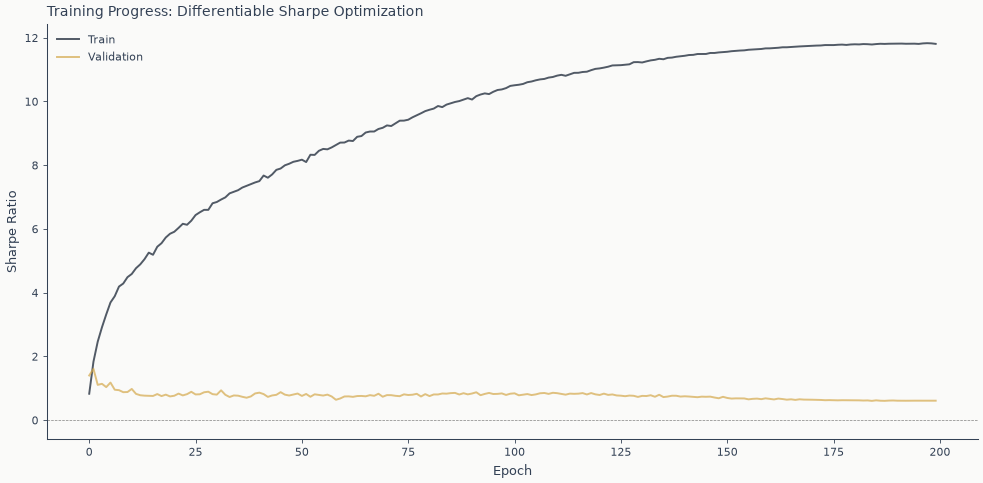

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
if train_sharpes and val_sharpes:
    ax.plot(train_sharpes, label="Train", alpha=0.7)
    ax.plot(val_sharpes, label="Validation", alpha=0.7)
    ax.legend()
else:
    ax.text(
        0.5,
        0.5,
        "Training history unavailable from cache",
        ha="center",
        va="center",
        transform=ax.transAxes,
    )
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Training Progress: Differentiable Sharpe Optimization")
fig.tight_layout()
fig.show()

**Finding**: Cache-first execution eliminates repeated training cost when the architecture and
data pipeline are unchanged, while preserving a retrain path for fresh experiments.

## 10. Out-of-Sample Evaluation

Load best model and compute test-period portfolio returns.
Compare with equal-weight and inverse-volatility baselines.

In [22]:
model.load_state_dict(best_state)
model.eval()

LSTMPortfolioNet(
  (lstm): LSTM(145, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=29, bias=True)
)

### Daily Return Extraction Helper

We evaluate each method on the same test windows by extracting the final step return from
each sliding sequence.

In [23]:
def compute_portfolio_returns(loader, model_fn):
    """Compute daily portfolio returns from a loader."""
    all_returns = []
    with torch.no_grad():
        for x_batch, r_batch in loader:
            x_batch = x_batch.to(DEVICE)
            r_batch = r_batch.to(DEVICE)
            w = model_fn(x_batch)
            port_r = (w * r_batch).sum(dim=-1)
            # Take last timestep per window (non-overlapping returns)
            all_returns.append(port_r[:, -1].cpu().numpy())
    return np.concatenate(all_returns)


# LSTM portfolio
lstm_returns = compute_portfolio_returns(test_loader, model)

### Equal-Weight Baseline

In [24]:
def equal_weight_fn(x):
    b, t, n, f = x.shape
    return torch.ones(b, t, n, device=x.device) / n


ew_returns = compute_portfolio_returns(test_loader, equal_weight_fn)

### Inverse-Volatility Baseline

In [25]:
def inv_vol_fn(x):
    # Use rolling vol from the last feature channel
    vol = x[:, :, :, -1].clamp(min=1e-6)  # (B, T, N)
    inv_vol = 1.0 / vol
    return inv_vol / inv_vol.sum(dim=-1, keepdim=True)


iv_returns = compute_portfolio_returns(test_loader, inv_vol_fn)

### Performance Comparison

In [26]:
def compute_metrics(returns, name, ann_factor=252.0):
    """Compute portfolio performance metrics."""
    r = pd.Series(returns)
    mu = r.mean() * ann_factor
    vol = r.std() * np.sqrt(ann_factor)
    sharpe = mu / (vol + 1e-8)
    cum = (1 + r).cumprod()
    max_dd = float((cum / cum.cummax() - 1).min())
    return {
        "Method": name,
        "Ann. Return": f"{mu:.1%}",
        "Ann. Vol": f"{vol:.1%}",
        "Sharpe": f"{sharpe:.2f}",
        "Max DD": f"{max_dd:.1%}",
    }


results = pd.DataFrame(
    [
        compute_metrics(lstm_returns, "LSTM Portfolio"),
        compute_metrics(ew_returns, "Equal Weight"),
        compute_metrics(iv_returns, "Inverse Volatility"),
    ]
)
results

,Method,Ann. Return,Ann. Vol,Sharpe,Max DD
0,LSTM Portfolio,2.3%,4.8%,0.48,-10.9%
1,Equal Weight,7.9%,12.1%,0.65,-18.4%
2,Inverse Volatility,5.5%,8.2%,0.67,-14.7%


**Finding**: The LSTM portfolio achieves the lowest volatility and drawdown but a lower
Sharpe ratio than both baselines, indicating it learned a conservative allocation that
does not compensate for its reduced return. Validating end-to-end allocators against
simple heuristics is essential before deploying added complexity.

### Equity Curves

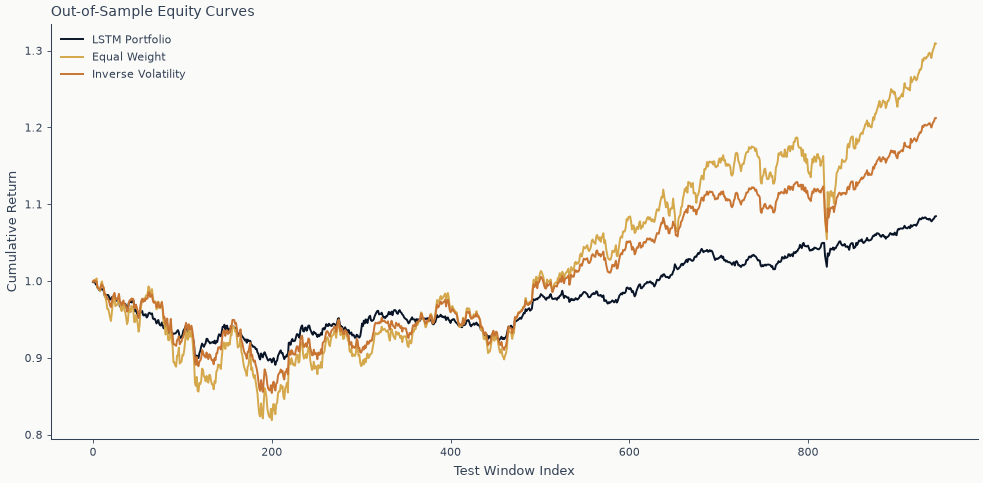

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
for returns_arr, label in [
    (lstm_returns, "LSTM Portfolio"),
    (ew_returns, "Equal Weight"),
    (iv_returns, "Inverse Volatility"),
]:
    cum = np.cumprod(1 + returns_arr)
    ax.plot(cum, label=label)
ax.set_xlabel("Test Window Index")
ax.set_ylabel("Cumulative Return")
ax.set_title("Out-of-Sample Equity Curves")
ax.legend()
fig.tight_layout()
fig.show()

**Trading implication**: If the LSTM curve only tracks heuristic baselines, a simpler allocator
is preferable due to lower implementation and monitoring risk.

## 11. Weight Analysis

Examine the learned allocation: how concentrated are the positions,
and which assets dominate?

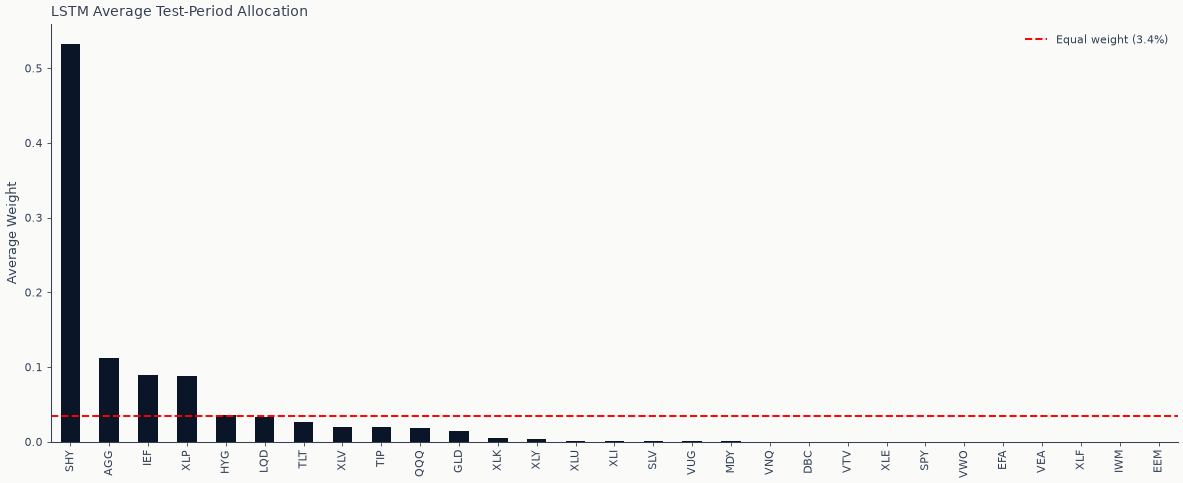

In [28]:
# Collect weights on test set
all_weights = []
model.eval()
with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(DEVICE)
        w = model(x_batch)
        all_weights.append(w[:, -1, :].cpu().numpy())

test_weights = np.concatenate(all_weights, axis=0)

# Average allocation
avg_weights = pd.Series(test_weights.mean(axis=0), index=UNIVERSE).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
avg_weights.plot(kind="bar", ax=ax)
ax.set_ylabel("Average Weight")
ax.set_title("LSTM Average Test-Period Allocation")
ax.axhline(1.0 / N_ASSETS, color="red", linestyle="--", label=f"Equal weight ({1 / N_ASSETS:.1%})")
ax.legend()
fig.tight_layout()
fig.show()

**Finding**: Persistent concentration in a small subset of ETFs indicates the model is learning
a structural allocation bias rather than purely time-varying tactical tilts.

### Weight Concentration Over Time

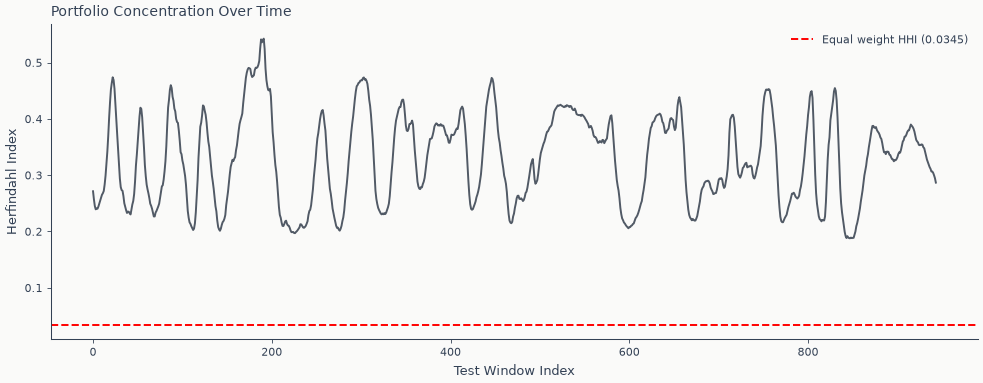

In [29]:
# Herfindahl index (concentration measure)
hhi = (test_weights**2).sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hhi, alpha=0.7)
ax.axhline(
    1.0 / N_ASSETS, color="red", linestyle="--", label=f"Equal weight HHI ({1 / N_ASSETS:.4f})"
)
ax.set_xlabel("Test Window Index")
ax.set_ylabel("Herfindahl Index")
ax.set_title("Portfolio Concentration Over Time")
ax.legend()
fig.tight_layout()
fig.show()

**Trading implication**: Higher concentration (HHI above equal-weight baseline) raises
idiosyncratic drawdown risk and should be paired with exposure constraints in production.

## 12. Realized Turnover (Sanity Check)

The training objective is a pure Sharpe loss with no turnover penalty (see
Takeaway 3), so realized turnover is an emergent property the loss does not
control. A full cost-grid sensitivity is deferred to Chapter 18; this notebook
reports realized turnover only as a sanity check on the magnitude of trading
the model implies.

In [30]:
# Mean per-rebalance Σ|Δw| across consecutive test-period weight vectors
turnover = np.abs(np.diff(test_weights, axis=0)).sum(axis=1)
avg_turnover = float(turnover.mean())
print(f"Realized turnover (mean Σ|Δw| per rebalance): {avg_turnover:.4f}")
print(f"Realized turnover (bps-equivalent, one-way): {avg_turnover * 10_000:.0f} bps")

Realized turnover (mean Σ|Δw| per rebalance): 0.0325
Realized turnover (bps-equivalent, one-way): 325 bps


**Interpretation**: Turnover is the bridge from apparent model edge to live
deployability. The number above is reported in raw weight-change units and as a
bps-equivalent one-way trade size; Chapter 18 attaches an explicit cost model and
compares the deployable Sharpe of this allocator against the simpler baselines.

## Key Takeaways

1. **End-to-end optimization is feasible but not free**: The LSTM directly maximizes
   Sharpe without intermediate predictions, yet it underperforms simple heuristics
   on this ETF universe — lower volatility and drawdown come at the cost of return.
2. **Simplicity is the point**: The entire model is ~50 lines of PyTorch.
   The differentiable Sharpe loss is the innovation, not the architecture.
3. **Realized turnover is ~325 bps-equivalent (one-way) per rebalance**: cost
   stress lives in Ch18, but the LSTM trained without an explicit cost-aware
   loss tends to carry meaningfully higher turnover than equal-weight or
   inverse-vol.
4. **Interpretability tradeoff**: Unlike predict-then-optimize, you cannot
   separately diagnose signal failure vs allocation failure.

**Next**: `12_vlstm_portfolio` introduces a TFT-style variable-selection block
in front of the LSTM encoder; `13_deepm_regime_robust` then adds the SoftMin
regime-robust loss and macro graph prior on top of that pipeline.

**Book**: §17.8 discusses the two-stage vs end-to-end tradeoff.